In [2]:
import os
import numpy as np
import rasterio as rio
from matplotlib import pyplot as plt

In [3]:
files = os.listdir('./data/')

In [25]:
fp = os.path.join('./data/', files[0])

with rio.open(fp) as src:
    shape = src.shape

print(shape)

(7793, 7793)


# Now, we retile

In [4]:
import os, glob, shlex, subprocess, textwrap

In [5]:
INPUT_DIR  = "./data/"     # folder with your big .tif/.tiff files
OUTPUT_DIR = "./retiled/"     # where you want the tiles written

# Create output folder if needed
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [11]:
TILE_SIZE_PX = (512, 512)     # (width, height) in pixels for each tile
RESAMPLING   = "bilinear"       # nearest|bilinear|cubic|cubicspline|lanczos...
OUTPUT_FORMAT = "GTiff"         # keep as GeoTIFF tiles
CO_OPTS = [
    "TILED=YES",
    "COMPRESS=LZW",             # or ZSTD if your GDAL has it: "COMPRESS=ZSTD"
    "BIGTIFF=YES"               # enable >4GB tiles if they happen
]

# Collect input files
tifs = sorted(glob.glob(os.path.join(INPUT_DIR, "*.tif")) +
              glob.glob(os.path.join(INPUT_DIR, "*.tiff")))

print(f"Found {len(tifs)} input files.")
for p in tifs[:5]:
    print(" -", os.path.basename(p))

Found 4 input files.
 - S2_daily_2024-01-03_masked.tif
 - S2_daily_2024-01-05_masked.tif
 - S2_daily_2024-01-08_masked.tif
 - S2_daily_2024-01-10_masked.tif


In [13]:
def run(cmd):
    print("\n$ " + cmd)
    completed = subprocess.run(cmd, shell=True)
    if completed.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {completed.returncode}")

# Helpful: allow GDAL to use all CPUs where possible
os.environ["GDAL_NUM_THREADS"] = "ALL_CPUS"
os.environ["NUM_THREADS"] = "ALL_CPUS"
os.environ["CPL_VSIL_CURL_ALLOWED_EXTENSIONS"] = ".tif,.tiff"  # harmless hint

for src in tifs:
    base = os.path.splitext(os.path.basename(src))[0]
    out_dir = os.path.join(OUTPUT_DIR, base)
    os.makedirs(out_dir, exist_ok=True)

    # Build -co arguments
    co_flags = " ".join("-co " + shlex.quote(x) for x in CO_OPTS)

    # Assemble the gdal_retile command
    # Docs: gdal_retile.py -targetDir <dir> -ps <tileX tileY> -r <resampling> -of <format> -co KEY=VALUE ...
    cmd = textwrap.dedent(f"""
        gdal_retile.py
          -targetDir {shlex.quote(out_dir)}
          -ps {TILE_SIZE_PX[0]} {TILE_SIZE_PX[1]}
          -r {RESAMPLING}
          -of {OUTPUT_FORMAT}
          {co_flags}
          {shlex.quote(src)}
    """).strip().replace("\n", " ")

    run(cmd)

print("\nAll done! Tiles are in:", OUTPUT_DIR)


$ gdal_retile.py   -targetDir ./retiled/S2_daily_2024-01-03_masked   -ps 512 512   -r bilinear   -of GTiff   -co TILED=YES -co COMPRESS=LZW -co BIGTIFF=YES   ./data/S2_daily_2024-01-03_masked.tif


Warning 1: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.


0...10...20...30...40...50...60...70...80...90...100 - done.

$ gdal_retile.py   -targetDir ./retiled/S2_daily_2024-01-05_masked   -ps 512 512   -r bilinear   -of GTiff   -co TILED=YES -co COMPRESS=LZW -co BIGTIFF=YES   ./data/S2_daily_2024-01-05_masked.tif


Warning 1: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.


0...10...20...30...40...50...60...70...80...90...100 - done.

$ gdal_retile.py   -targetDir ./retiled/S2_daily_2024-01-08_masked   -ps 512 512   -r bilinear   -of GTiff   -co TILED=YES -co COMPRESS=LZW -co BIGTIFF=YES   ./data/S2_daily_2024-01-08_masked.tif


Warning 1: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.


0...10...20...30...40...50...60...70...80...90...100 - done.

$ gdal_retile.py   -targetDir ./retiled/S2_daily_2024-01-10_masked   -ps 512 512   -r bilinear   -of GTiff   -co TILED=YES -co COMPRESS=LZW -co BIGTIFF=YES   ./data/S2_daily_2024-01-10_masked.tif


Warning 1: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.


0...10...20...30...40...50...60...70...80...90...100 - done.

All done! Tiles are in: ./retiled/


In [14]:
output = os.listdir('./retiled/')
img = output[0]
output_files = os.listdir(os.path.join('./retiled/', img))
ex_fp = os.path.join('./retiled/', img, output_files[0])

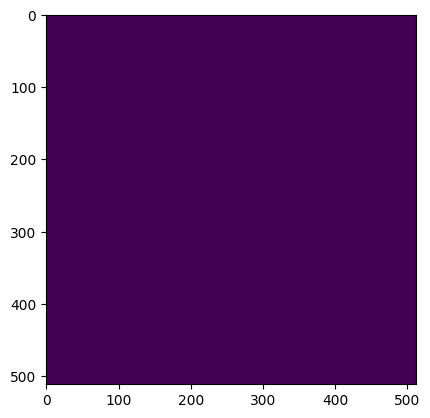

In [17]:
with rio.open(ex_fp) as src:
    data = src.read()

plt.imshow(data[0, :, :])

In [26]:
(data == 0).all() == True

np.True_

In [ ]:
data.